<a href="https://colab.research.google.com/github/Kard00/Machine_Learning/blob/main/Criando_um_modelo_de_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
#  IMPORTAR BIBLIOTECAS E CARREGAR DADOS
# ============================================
import tensorflow as tf
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Carregar conjunto de dados Iris
iris = load_iris()
X = iris.data # Características: comprimento/largura sépala e pétala
y = iris.target # Classes: 0=Setosa, 1=Versicolor, 2=Virginica

print("Formato dos dados X:", X.shape)
print("Classes disponíveis:", iris.target_names)

Formato dos dados X: (150, 4)
Classes disponíveis: ['setosa' 'versicolor' 'virginica']


In [2]:
# ============================================
#  PRÉ-PROCESSAMENTO DOS DADOS
# ============================================
# 1. Dividir em treino e teste: 80% treino, 20% teste
# random_state=42 garante que a divisão seja sempre a mesma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Normalizar os dados: deixa tudo na mesma escala
# Isso evita que uma característica "domine" as outras só por ter valores maiores
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # aprende a escala e aplica no treino
X_test = scaler.transform(X_test) # aplica a mesma escala no teste

print("Tamanho treino:", X_train.shape[0], "amostras")
print("Tamanho teste:", X_test.shape[0], "amostras")

Tamanho treino: 120 amostras
Tamanho teste: 30 amostras


In [3]:
# ============================================
#  CONSTRUIR O MODELO COM TENSORFLOW
# ============================================
# Modelo de rede neural simples: 4 entradas -> 10 neurônios -> 3 saídas
model = tf.keras.Sequential([
    # Camada de entrada + primeira camada oculta com 10 neurônios
    tf.keras.layers.Dense(10, activation='relu', input_shape=(4,)),
    # Camada de saída com 3 neurônios, um pra cada espécie de Iris
    # softmax transforma a saída em probabilidades que somam 1
    tf.keras.layers.Dense(3, activation='softmax')
])

# Compilar o modelo: define como ele vai aprender
model.compile(optimizer='adam', # otimizador que ajusta os pesos
              loss='sparse_categorical_crossentropy', # função de erro pra classificação
              metrics=['accuracy']) # métrica que queremos acompanhar

model.summary() # mostra a arquitetura do modelo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ============================================
#  TREINAR O MODELO
# ============================================
# epochs=100: vai passar 100 vezes por todos os dados de treino
# validation_data: usa os dados de teste pra verificar se não está decorando
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_data=(X_test, y_test),
                    verbose=0) # verbose=0 pra não poluir a saída

print("Treinamento concluído!")

Treinamento concluído!


Acurácia no conjunto de teste: 90.00%


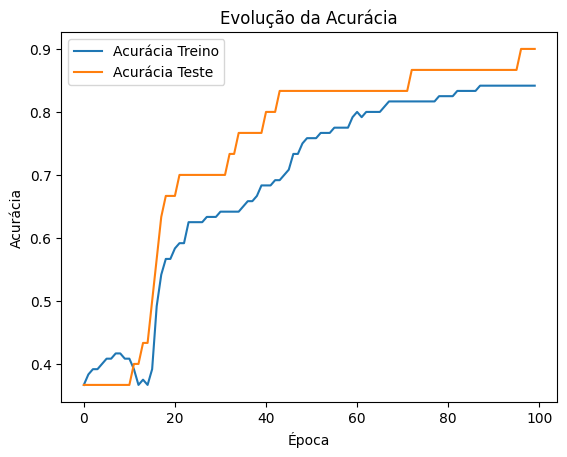

In [5]:
# ============================================
# AVALIAR O MODELO
# ============================================
# Avalia a precisão final usando os dados de teste que o modelo nunca viu
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Acurácia no conjunto de teste: {accuracy * 100:.2f}%")

# Mostra gráfico da evolução do treino
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Acurácia Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia Teste')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

In [6]:
# ============================================
# FAZER PREVISÕES
# ============================================
# Pega as 5 primeiras amostras do teste pra prever
predictions = model.predict(X_test[:5])
predicted_classes = tf.argmax(predictions, axis=1)

print("Resultados das previsões:")
for i in range(5):
    print(f"Amostra {i+1}: Real = {iris.target_names[y_test[i]]} | Previsto = {iris.target_names[predicted_classes[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Resultados das previsões:
Amostra 1: Real = versicolor | Previsto = versicolor
Amostra 2: Real = setosa | Previsto = setosa
Amostra 3: Real = virginica | Previsto = virginica
Amostra 4: Real = versicolor | Previsto = virginica
Amostra 5: Real = versicolor | Previsto = virginica


In [7]:
# Resposta da Pergunta: Avaliando os resultados
# Pergunta: Por que o pré-processamento dos dados (como normalização e divisão entre treino e teste) é essencial para a construção de um modelo eficiente?

# Resposta:
# O pré-processamento é essencial por 2 motivos principais:

# Divisão Treino/Teste: Separamos os dados pra simular um cenário real. O modelo aprende com os dados de treino e testamos com dados que ele nunca viu. Sem isso, não temos como saber se o modelo realmente aprendeu padrões ou se só decorou as respostas. Um modelo com 100% de acerto no treino mas 50% no teste sofre de overfitting e é inútil na prática.
# Normalização com StandardScaler: As 4 características do Iris têm escalas diferentes. O comprimento da sépala pode ir de 4 a 8 cm, enquanto a largura da pétala vai de 0.1 a 2.5 cm. Redes neurais são sensíveis a isso: sem normalizar, a característica com números maiores teria peso muito maior no aprendizado, desbalanceando o modelo. A normalização coloca todas na mesma escala, com média 0 e desvio 1, garantindo que o modelo dê importância justa pra cada característica e convirja mais rápido durante o treino.
# Sem esses dois passos, o modelo fica enviesado, demora mais pra treinar e tem desempenho ruim com dados novos.

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt


In [9]:
x_train = tf.constant([[1.0], [2.0], [3.0], [4.0]])
y_train = tf.constant([[2.0], [4.0], [6.0], [8.0]])
# Definimos os dados de entra (X) e de saída (Y) para treinar o modelo
#estamos usando pares de entrada que representam uma relação linear (o dobro das entradas)

In [10]:
# modelo de regressão linear simples
model = Sequential()
model.add(Dense(units=1, input_shape=(1,)))
model.compile(optimizer='sgd', loss='mean_squared_error')

In [11]:
# Definimos o modelo de regressão linear simples usando a API keras sequential
# o modelo consiste em uma única camada densa (ou totalmente conectada) com um neurônio (ou uma unidade) e uma entrada
# estamos usandoa função de perda de (loss) erro quadrático médio (mean_squared_error)
# otimizador sgd gradiente estocástica

In [12]:
# treinamento do modelo
history = model.fit(x_train, y_train, epochs=1000, verbose=0)

In [13]:
# nesta seção, trenamos o modelo usando dados de exemplo
# executamos 1000 épocas de treinamento (epochs) e armazenamos o histórico do treinamento em history
#  o argumento verbiose=0 faz com que o trenamento seja executado em modo silencioso, sem exibir informações do progresso.#

In [14]:
x_new = tf.constant([[5.0]])
prediction = model.predict(x_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [15]:
# aqui fazemos uma previsão de treinamento
# informamos uma nova entrada e calculamos a previsao. o resultado é impresso na tela

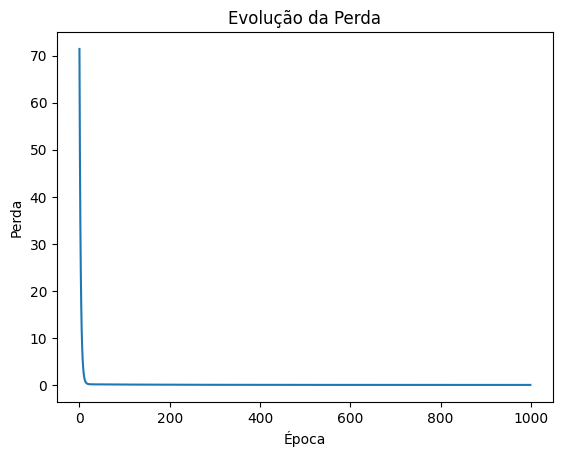

In [16]:
# plotar os resultados
plt.plot(history.history['loss'])
plt.title('Evolução da Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.show()